In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow gensim nltk contractions wordcloud streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python sms_spam_complete.py

python3: can't open file '/content/sms_spam_complete.py': [Errno 2] No such file or directory


In [ ]:
!python -m streamlit run sms_spam_complete.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: sms_spam_complete.py


In [ ]:
import sys
_STREAMLIT_MODE = "streamlit" in sys.modules or any(
    "streamlit" in a for a in sys.argv
)

In [ ]:
import re
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
if not _STREAMLIT_MODE:
    matplotlib.use("Agg")          # change to "Agg" if no display
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
import nltk
for pkg in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
import contractions as ctr

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec

In [ ]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/spamvsham.csv"   # file path

df = pd.read_csv(
    DATASET_PATH,
    sep=",",  # Corrected separator from tab to comma
    header=None,
    names=["label", "text"],
    encoding="latin-1",
    usecols=[0, 1]  # Ensure only the first two columns are read
)

In [ ]:
print(df.head(8).to_string())
print(f"\nShape        : {df.shape}")
print(f"Label counts :\n{df['label'].value_counts()}")

  label                                                                                                                                                         text
0    v1                                                                                                                                                           v2
1   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
2   ham                                                                                                                                Ok lar... Joking wif u oni...
3  spam  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
4   ham                                                                                                            U dun say so early hor... U c already then say...
5   ham   

In [ ]:
# Binary encoding  ham=0  spam=1
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

Text Cleanning

In [ ]:
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

In [ ]:
def clean_text(raw: str) -> str:
    """Full NLP pre-processing pipeline."""
    text = ctr.fix(raw)                         # expand contractions
    text = text.lower()                         # lowercase
    text = re.sub(r"https?://\S+|www\.\S+", "", text)  # URLs
    text = re.sub(r"#\w+", "", text)            # #hashtags
    text = re.sub(r"\d+", "", text)             # numbers
    text = re.sub(r"[^a-z\s]", "", text)        # special chars
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(w)
              for w in tokens if w not in STOP_WORDS]
    return " ".join(tokens)

In [ ]:
df["clean_text"] = df["text"].apply(clean_text)
print(df[["label", "text", "clean_text"]].head(6).to_string())

  label                                                                                                                                                         text                                                                                                  clean_text
0    v1                                                                                                                                                           v2                                                                                                           v
1   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                          go jurong point crazy available bugis n great world la e buffet cine got amore wat
2   ham                                                                                                                                Ok lar... Joking wif u oni...                 

Visualize:Word Clouds and Freq Words


[Plotting word clouds …]


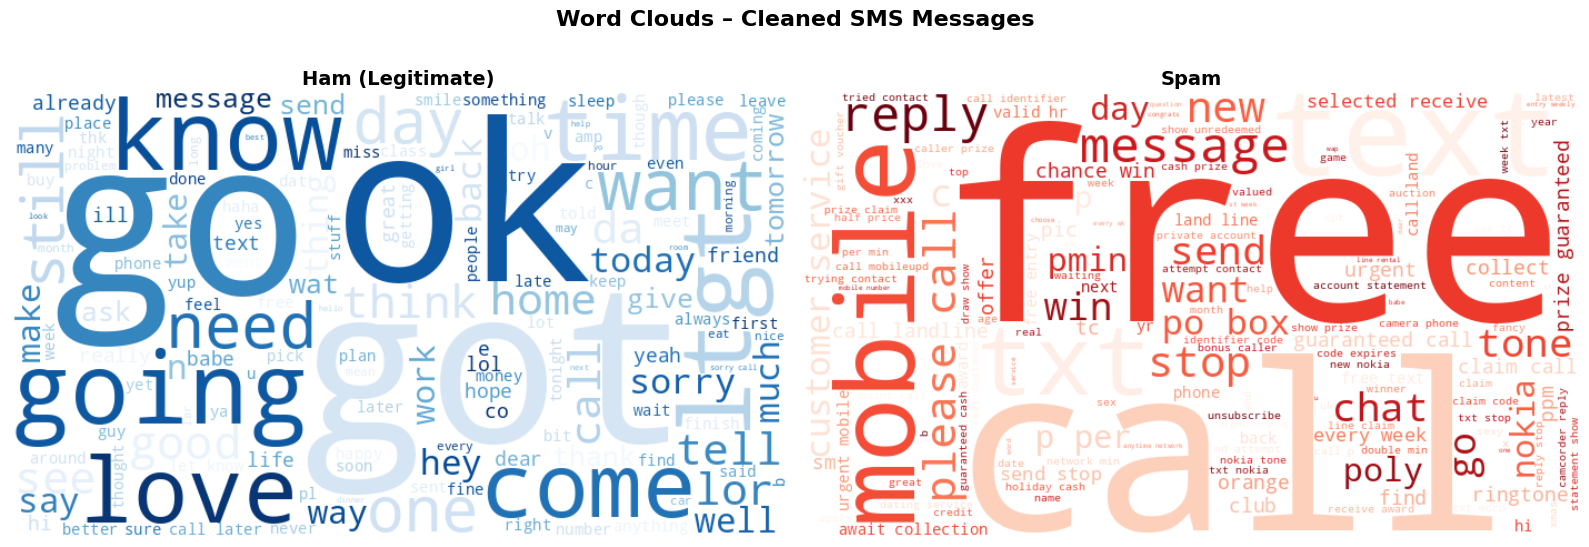

In [ ]:
print("\n[Plotting word clouds …]")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Word Clouds – Cleaned SMS Messages", fontsize=16, fontweight="bold")

for ax, lbl, cmap in zip(axes, ["ham", "spam"], ["Blues", "Reds"]):
    corpus = " ".join(df[df["label"] == lbl]["clean_text"])
    wc = WordCloud(width=700, height=400, colormap=cmap,
                   background_color="white", max_words=150).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Ham (Legitimate)" if lbl == "ham" else "Spam",
                 fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
display(fig)

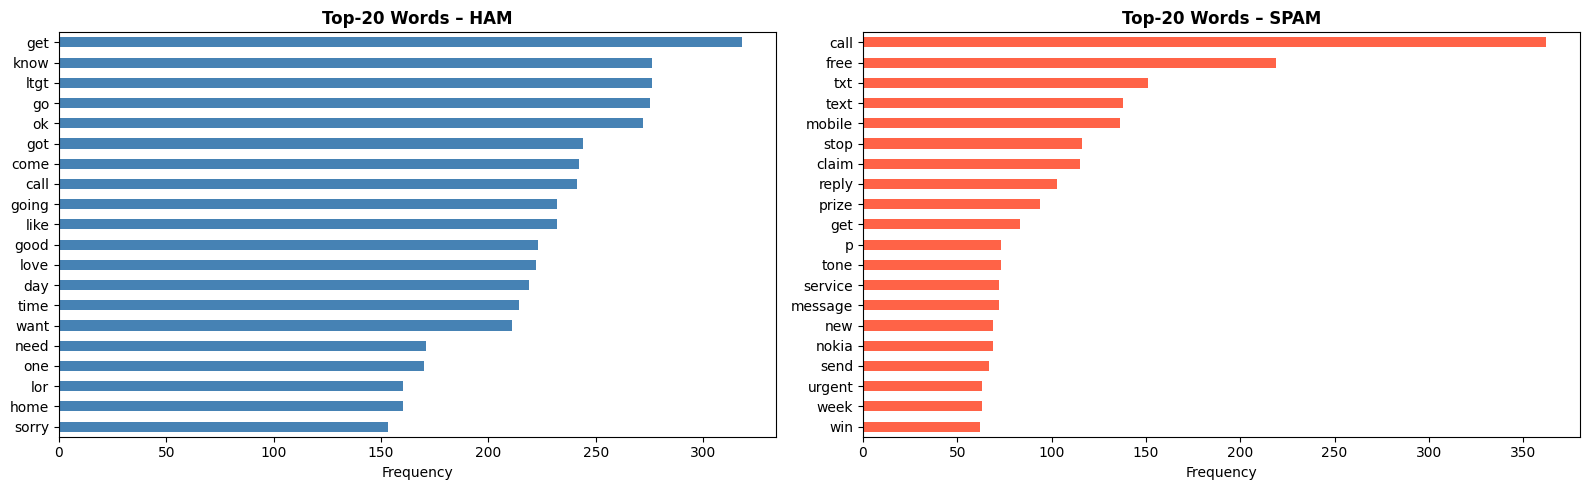

In [ ]:
# Top-20 words per class
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
for ax, lbl, colour in zip(axes2, ["ham", "spam"], ["steelblue", "tomato"]):
    freq = (pd.Series(" ".join(df[df["label"] == lbl]["clean_text"]).split())
            .value_counts().head(20))
    freq.sort_values().plot(kind="barh", ax=ax, color=colour)
    ax.set_title(f"Top-20 Words – {lbl.upper()}", fontweight="bold")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()
display(fig2)

Training/testing

In [ ]:
df_cleaned = df[df['label'] != 'v1'].copy() # Filter out the header row 'v1'

X = df_cleaned["clean_text"].values
y = df_cleaned["label_enc"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain : {len(X_train)} samples | Test : {len(X_test)} samples")


Train : 4457 samples | Test : 1115 samples


Tokenization

In [ ]:
VOCAB_SIZE = 10_000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

print(f"Vocabulary size (actual): {len(tokenizer.word_index)}")

Vocabulary size (actual): 6876


Padding

In [ ]:
lengths = [len(s) for s in train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN,
                             padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN,
                             padding="post", truncating="post")

print(f"X_train_pad : {X_train_pad.shape}")
print(f"X_test_pad  : {X_test_pad.shape}")

Max sequence length (95th percentile): 18
X_train_pad : (4457, 18)
X_test_pad  : (1115, 18)


Model Building

In [ ]:
EMBED_DIM  = 64
UNITS      = 64
EPOCHS     = 20
BATCH_SIZE = 64

early_stop = EarlyStopping(monitor="val_loss", patience=3,
                           restore_best_weights=True, verbose=1)

RNN

In [ ]:
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(UNITS),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
], name="Model1_SimpleRNN")

model1.compile(optimizer="adam",
               loss="binary_crossentropy",
               metrics=["accuracy"])

model1.build(input_shape=(None, MAX_LEN))
model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

LSTM + Trainable Embeddings

In [ ]:
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(UNITS),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1,  activation="sigmoid")
], name="Model2_LSTM_Trainable")

model2.compile(optimizer="adam",
               loss="binary_crossentropy",
               metrics=["accuracy"])

model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "Model2_LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

LSTM + Word2Vec Embeddings

In [ ]:
model3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=True),
    LSTM(UNITS),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
], name="Model3_LSTM_Word2Vec")

model3.compile(optimizer="adam",
               loss="binary_crossentropy",
               metrics=["accuracy"])

model3.build(input_shape=(None, MAX_LEN))
model3.summary()

Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 18, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Trainning and Evaluation

In [ ]:
def train_model(model, label):
    print(f"\n{'='*55}\n  Training: {label}\n{'='*55}")
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.10,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    return history


hist1 = train_model(model1, "Model 1 – Simple RNN")
hist2 = train_model(model2, "Model 2 – LSTM Trainable Emb")
hist3 = train_model(model3, "Model 3 – LSTM Word2Vec Emb")


  Training: Model 1 – Simple RNN
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9955 - loss: 0.0243 - val_accuracy: 0.9731 - val_loss: 0.1035
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9965 - loss: 0.0154 - val_accuracy: 0.9552 - val_loss: 0.1800
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0116 - val_accuracy: 0.9709 - val_loss: 0.1270
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

  Training: Model 2 – LSTM Trainable Emb
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9935 - loss: 0.0253 - val_accuracy: 0.9798 - val_loss: 0.0997
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9968 - loss: 0.0137 - val_accuracy: 0.9619 - val_loss: 0.1563
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9980 - loss: 0.0071 - val_accuracy: 0.9753 - val_loss: 0.1336
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

 

Trainning us Validations Curves

In [ ]:
%matplotlib inline

Simple RNN

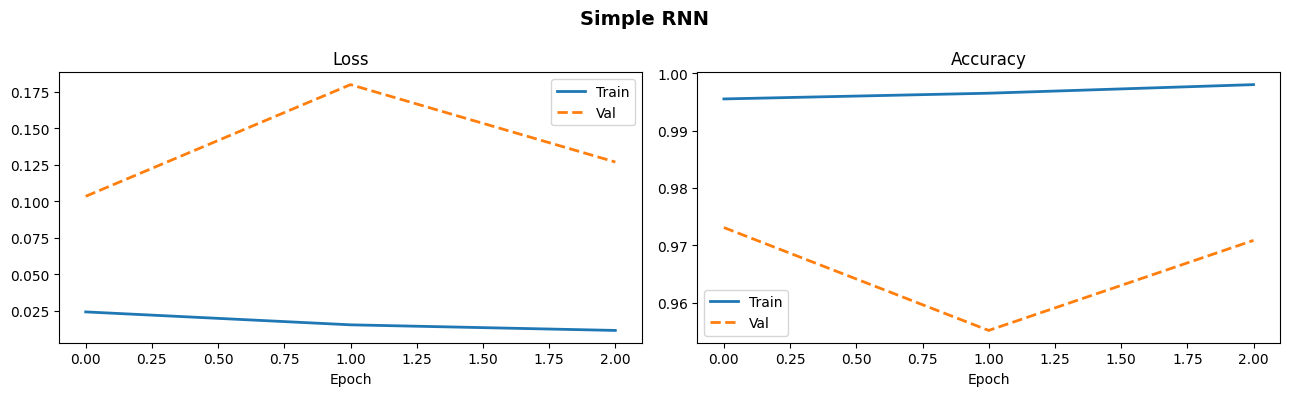

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Simple RNN", fontsize=14, fontweight="bold")

ax1.plot(hist1.history["loss"],      label="Train", lw=2)
ax1.plot(hist1.history["val_loss"],  label="Val",   lw=2, ls="--")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist1.history["accuracy"],     label="Train", lw=2)
ax2.plot(hist1.history["val_accuracy"], label="Val",   lw=2, ls="--")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

LSTM Trainable Emb

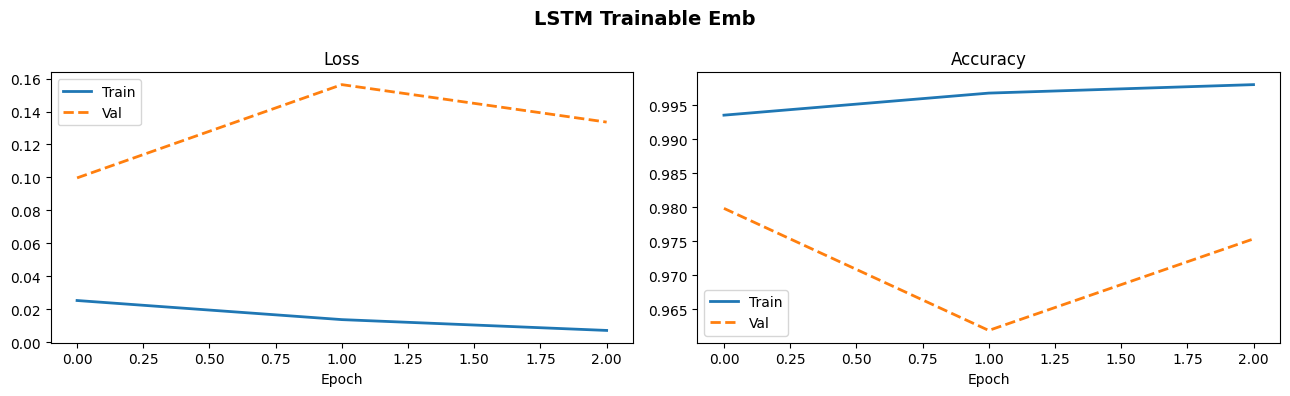

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("LSTM Trainable Emb", fontsize=14, fontweight="bold")

ax1.plot(hist2.history["loss"],      label="Train", lw=2)
ax1.plot(hist2.history["val_loss"],  label="Val",   lw=2, ls="--")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist2.history["accuracy"],     label="Train", lw=2)
ax2.plot(hist2.history["val_accuracy"], label="Val",   lw=2, ls="--")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

LSTM Word2Vec Emb

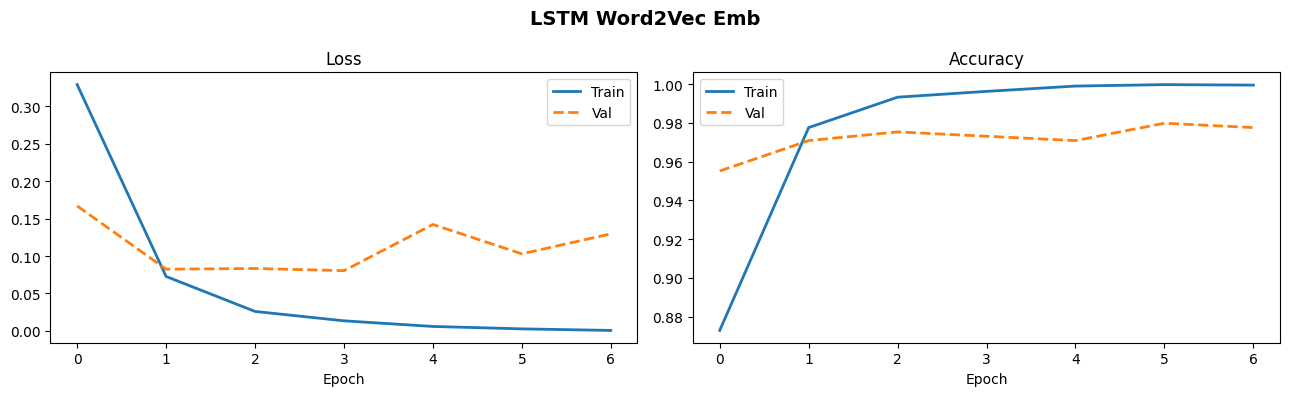

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("LSTM Word2Vec Emb", fontsize=14, fontweight="bold")

ax1.plot(hist3.history["loss"],      label="Train", lw=2)
ax1.plot(hist3.history["val_loss"],  label="Val",   lw=2, ls="--")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(hist3.history["accuracy"],     label="Train", lw=2)
ax2.plot(hist3.history["val_accuracy"], label="Val",   lw=2, ls="--")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

Evalaute each model

Simple RNN

Simple RNN

  Accuracy: 0.9704
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98       966
        Spam       0.90      0.88      0.89       149

    accuracy                           0.97      1115
   macro avg       0.94      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



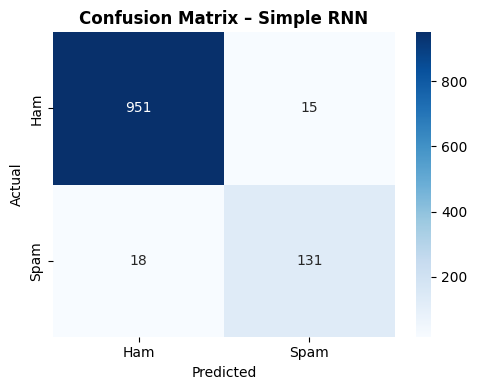

In [ ]:
probs1 = model1.predict(X_test_pad, verbose=0).flatten()
p1     = (probs1 >= 0.5).astype(int)
acc1   = accuracy_score(y_test, p1)

print(f"Simple RNN\n")
print(f"  Accuracy: {acc1:.4f}")
print(classification_report(y_test, p1, target_names=["Ham", "Spam"]))

cm1 = confusion_matrix(y_test, p1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix – Simple RNN", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

LSTM Trainable Emb

LSTM Trainable Emb

  Accuracy: 0.9785
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.96      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



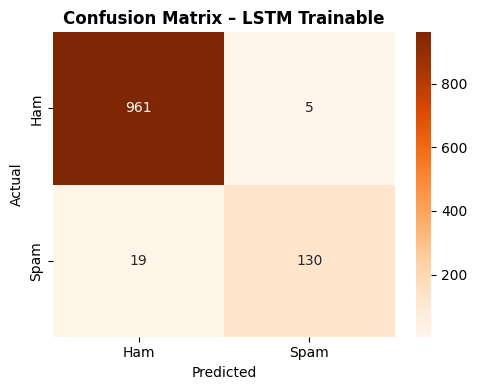

In [ ]:
probs2 = model2.predict(X_test_pad, verbose=0).flatten()
p2     = (probs2 >= 0.5).astype(int)
acc2   = accuracy_score(y_test, p2)

print(f"LSTM Trainable Emb\n")
print(f"  Accuracy: {acc2:.4f}")
print(classification_report(y_test, p2, target_names=["Ham", "Spam"]))

cm2 = confusion_matrix(y_test, p2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix – LSTM Trainable", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

LSTM Word2Vec

LSTM Word2Vec Emb

  Accuracy: 0.9821
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



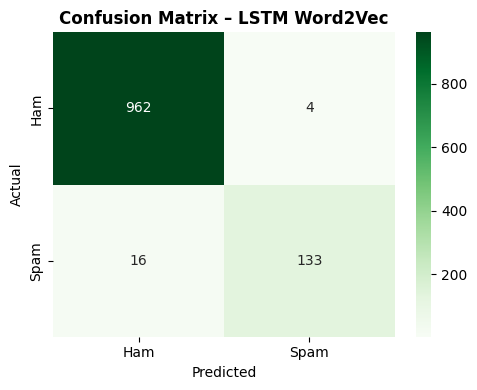

In [ ]:
probs3 = model3.predict(X_test_pad, verbose=0).flatten()
p3     = (probs3 >= 0.5).astype(int)
acc3   = accuracy_score(y_test, p3)

print(f"LSTM Word2Vec Emb\n")
print(f"  Accuracy: {acc3:.4f}")
print(classification_report(y_test, p3, target_names=["Ham", "Spam"]))

cm3 = confusion_matrix(y_test, p3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm3, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix – LSTM Word2Vec", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Comparision

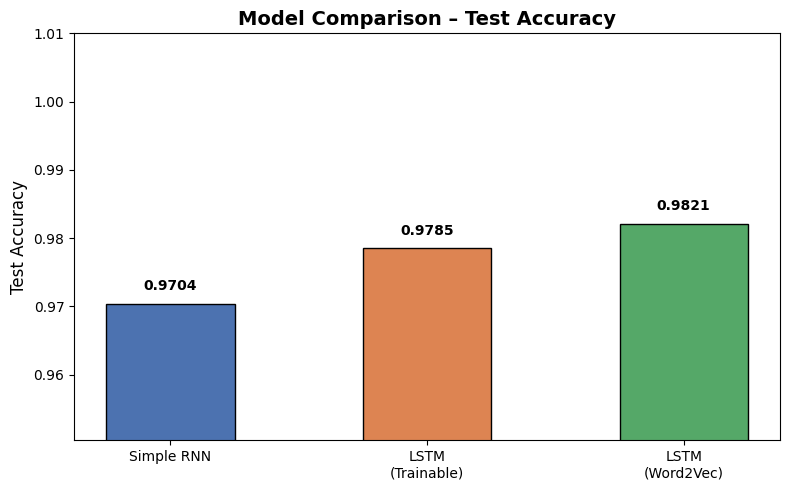

In [ ]:
model_names = ["Simple RNN", "LSTM\n(Trainable)", "LSTM\n(Word2Vec)"]
accuracies  = [acc1, acc2, acc3]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies,
               color=["#4C72B0", "#DD8452", "#55A868"],
               edgecolor="black", width=0.5)
plt.ylim(min(accuracies) - 0.02, 1.01)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Model Comparison – Test Accuracy", fontsize=14, fontweight="bold")
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Error Analysis

In [ ]:
misclassified = np.where(p3 != y_test)[0]
print(f"\nTotal misclassified samples: {len(misclassified)}")

print("\n--- 3 Misclassified Examples ---")
reasons = {
    "spam→ham": "Short spam message with no explicit spam keywords; the model lacked "
                "enough signal to flag it as spam.",
    "ham→spam": "Ham message contains promotional words (e.g. 'free', 'win') that "
                "strongly correlate with spam in the training data.",
}
for i, idx in enumerate(misclassified[:3]):
    actual    = "spam" if y_test[idx] == 1 else "ham"
    predicted = "spam" if p3[idx]    == 1 else "ham"
    direction = f"{actual}→{predicted}"
    reason    = reasons.get(direction, "Ambiguous language confuses the model.")
    print(f"\n  Example {i+1}")
    print(f"    Raw text   : {X_test[idx][:120]}")
    print(f"    Actual     : {actual.upper()}")
    print(f"    Predicted  : {predicted.upper()}")
    print(f"    Reason     : {reason}")


Total misclassified samples: 20

--- 3 Misclassified Examples ---

  Example 1
    Raw text   : freemsg hey darling week word back would like fun still tb ok xxx std chgs send rcv
    Actual     : SPAM
    Predicted  : HAM
    Reason     : Short spam message with no explicit spam keywords; the model lacked enough signal to flag it as spam.

  Example 2
    Raw text   : great p diddy neighbor come toothpaste every morning
    Actual     : HAM
    Predicted  : SPAM
    Reason     : Ham message contains promotional words (e.g. 'free', 'win') that strongly correlate with spam in the training data.

  Example 3
    Raw text   : ringtoneking
    Actual     : SPAM
    Predicted  : HAM
    Reason     : Short spam message with no explicit spam keywords; the model lacked enough signal to flag it as spam.


Save Artifacts for GUI

In [ ]:
import pickle

model3.save("best_model.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("config.pkl", "wb") as f:
    pickle.dump({"MAX_LEN": MAX_LEN, "THRESHOLD": 0.5}, f)

print("Model saved successfully!")

Model saved successfully!


4.5.5 Streamlit GUI

In [ ]:
!pip install streamlit -q

In [ ]:
%%writefile sms_app.py
import re, pickle
import numpy as np
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk, contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure resources are downloaded
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

@st.cache_resource
def load_artifacts():
    model = tf.keras.models.load_model('best_model.keras')
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    with open('config.pkl', 'rb') as f:
        cfg = pickle.load(f)
    return model, tokenizer, cfg['MAX_LEN'], cfg['THRESHOLD']

try:
    model, tokenizer, MAX_LEN, THRESHOLD = load_artifacts()
except Exception as e:
    st.error(f'Error loading model: {e}')

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text):
    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens if w not in STOP_WORDS]
    return ' '.join(tokens)

def predict(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = float(model.predict(padded, verbose=0)[0][0])
    return prob, cleaned

st.title('SMS Spam Detector')
sms = st.text_area('Enter SMS message here:', height=150)

if st.button('Classify'):
    if sms.strip():
        prob, cleaned = predict(sms)
        label = 'SPAM' if prob >= THRESHOLD else 'HAM'
        st.subheader(f'Result: {label}')
        st.write(f'Confidence: {prob:.2%}')
    else:
        st.warning('Please enter text.')

Overwriting sms_app.py


In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run sms_app.py &>/dev/null &
import time
time.sleep(3)
print("Streamlit started!")

Streamlit started!


In [ ]:
!curl -s ifconfig.me

34.125.126.184

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧your url is: https://major-terms-decide.loca.lt
^C


In [ ]:
!pip install pyngrok -q
from pyngrok import ngrok

In [ ]:
from pyngrok import ngrok
from google.colab import userdata
import time
import os

try:
    # 1. Clean up existing processes
    !pkill -f streamlit
    ngrok.kill()

    # 2. Setup ngrok auth
    raw_token = userdata.get('NGROK_AUTH_TOKEN')
    token = raw_token.split(' ')[-1].strip()
    ngrok.set_auth_token(token)

    # 3. Launch Streamlit with explicit host and port settings
    # Using --server.address=0.0.0.0 ensures it listens on all interfaces
    get_ipython().system_raw('streamlit run sms_app.py --server.port 8501 --server.address 0.0.0.0 > logs.txt 2>&1 &')

    print("Waiting for Streamlit to initialize...")
    time.sleep(8)  # Increased wait time for model loading

    # 4. Connect Tunnel
    public_url = ngrok.connect(8501)
    print(f'\n Deployment Successful!')
    print(f'Public URL: {public_url}')

    # 5. Display Logs for debugging
    print('\n--- Current Server Logs ---')
    if os.path.exists('logs.txt'):
        with open('logs.txt', 'r') as f:
            print(f.read())
    else:
        print("Log file not found.")

except Exception as e:
    print(f'Error during deployment: {e}')

Waiting for Streamlit to initialize...

 Deployment Successful!
Public URL: NgrokTunnel: "https://bakeshop-moonshine-wolf.ngrok-free.dev" -> "http://localhost:8501"

--- Current Server Logs ---


2026-05-07 05:26:19.217 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.126.184:8501




#Save in the Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# Save all important files to Drive
shutil.copy("best_model.keras", "/content/drive/MyDrive/best_model.keras")
shutil.copy("tokenizer.pkl",    "/content/drive/MyDrive/tokenizer.pkl")
shutil.copy("config.pkl",       "/content/drive/MyDrive/config.pkl")
shutil.copy("sms_app.py",       "/content/drive/MyDrive/sms_app.py")

print("All files saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive!


Run this during viva

In [86]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("/content/drive/MyDrive/best_model.keras", "best_model.keras")
shutil.copy("/content/drive/MyDrive/tokenizer.pkl",    "tokenizer.pkl")
shutil.copy("/content/drive/MyDrive/config.pkl",       "config.pkl")
shutil.copy("/content/drive/MyDrive/sms_app.py",       "sms_app.py")

print("Files restored!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files restored!


In [87]:
!pip install streamlit pyngrok contractions wordcloud gensim -q

In [88]:
!pkill -f streamlit
!streamlit run sms_app.py &>/dev/null &

import time
time.sleep(3)

from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(f"\n Open this link: {public_url}")


 Open this link: NgrokTunnel: "https://bakeshop-moonshine-wolf.ngrok-free.dev" -> "http://localhost:8501"
